## 1. Loading libraries

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Import classifiers
from sklearn.ensemble import (

    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV # Tuning the model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
) # Check model performance
from xgboost import XGBClassifier

## 2. Loading data

In [8]:
# Load csv file
df = pd.read_csv(r'C:\Users\obandohe\OneDrive - Stichting Deltares\Documents\DELTARES_PROJECTS\2025\05_Data_Fusion_Hanzelijn\01_DATABASE\trainin_data\training_data_DAS_Boreholes_allSpectra.csv')
df.head()

# filter depth 


,x_coord,y_coord,surface,end,z_top,cwt_f10,cwt_f12,cwt_f14,cwt_f16,cwt_f18,...,cwt_f28,cwt_f30,cwt_f32,cwt_f34,cwt_f36,cwt_f38,cwt_f40,Borehole_name,DAS_name,train_number
0,192733.7797,502794.1986,0.5,-4.0,NaN,1.076386e-08,9.106597e-09,8.148863e-09,8.861477e-09,1.134860e-08,...,6.555838e-09,4.817998e-09,4.130289e-09,4.185089e-09,4.000694e-09,3.395640e-09,2.662845e-09,21D0187,120,1
1,192733.7797,502794.1986,0.5,-4.0,NaN,1.621881e-08,1.673675e-08,1.316290e-08,9.998138e-09,7.579071e-09,...,3.884681e-09,3.450131e-09,2.839789e-09,2.919093e-09,3.366338e-09,2.850020e-09,2.007361e-09,21D0187,120,2
2,192733.7797,502794.1986,0.5,-4.0,NaN,7.020905e-09,7.303333e-09,7.459542e-09,6.462979e-09,6.825903e-09,...,4.477866e-09,3.327283e-09,2.393933e-09,2.083780e-09,2.097917e-09,1.666042e-09,1.243277e-09,21D0187,120,3
3,192733.7797,502794.1986,0.5,-4.0,NaN,1.681279e-08,2.045639e-08,2.096986e-08,1.710342e-08,9.242841e-09,...,4.235343e-09,3.321755e-09,1.891760e-09,1.352677e-09,1.397756e-09,1.394058e-09,1.243425e-09,21D0187,120,4
4,192733.7797,502794.1986,0.5,-4.0,NaN,1.902163e-08,2.353274e-08,2.060049e-08,1.518859e-08,9.125478e-09,...,2.925498e-09,2.565792e-09,2.469179e-09,2.456288e-09,2.235533e-09,1.760190e-09,1.447451e-09,21D0187,120,5


In [9]:
df

,x_coord,y_coord,surface,end,z_top,cwt_f10,cwt_f12,cwt_f14,cwt_f16,cwt_f18,...,cwt_f28,cwt_f30,cwt_f32,cwt_f34,cwt_f36,cwt_f38,cwt_f40,Borehole_name,DAS_name,train_number
0,192733.7797,502794.1986,0.50,-4.0,NaN,1.076386e-08,9.106597e-09,8.148863e-09,8.861477e-09,1.134860e-08,...,6.555838e-09,4.817998e-09,4.130289e-09,4.185089e-09,4.000694e-09,3.395640e-09,2.662845e-09,21D0187,120,1
1,192733.7797,502794.1986,0.50,-4.0,NaN,1.621881e-08,1.673675e-08,1.316290e-08,9.998138e-09,7.579071e-09,...,3.884681e-09,3.450131e-09,2.839789e-09,2.919093e-09,3.366338e-09,2.850020e-09,2.007361e-09,21D0187,120,2
2,192733.7797,502794.1986,0.50,-4.0,NaN,7.020905e-09,7.303333e-09,7.459542e-09,6.462979e-09,6.825903e-09,...,4.477866e-09,3.327283e-09,2.393933e-09,2.083780e-09,2.097917e-09,1.666042e-09,1.243277e-09,21D0187,120,3
3,192733.7797,502794.1986,0.50,-4.0,NaN,1.681279e-08,2.045639e-08,2.096986e-08,1.710342e-08,9.242841e-09,...,4.235343e-09,3.321755e-09,1.891760e-09,1.352677e-09,1.397756e-09,1.394058e-09,1.243425e-09,21D0187,120,4
4,192733.7797,502794.1986,0.50,-4.0,NaN,1.902163e-08,2.353274e-08,2.060049e-08,1.518859e-08,9.125478e-09,...,2.925498e-09,2.565792e-09,2.469179e-09,2.456288e-09,2.235533e-09,1.760190e-09,1.447451e-09,21D0187,120,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,192091.2289,503242.8083,0.39,-3.2,1.6,3.010599e-09,3.354252e-09,3.238770e-09,2.641635e-09,2.451518e-09,...,1.779586e-09,1.548292e-09,1.085591e-09,8.140949e-10,8.383240e-10,8.748990e-10,7.880711e-10,21D0165,920,46
1496,192091.2289,503242.8083,0.39,-3.2,1.6,1.274083e-09,1.386502e-09,1.447824e-09,1.629633e-09,2.188472e-09,...,5.946385e-10,5.242853e-10,7.200245e-10,8.182009e-10,7.085472e-10,4.396499e-10,2.950575e-10,21D0165,920,47
1497,192091.2289,503242.8083,0.39,-3.2,1.6,1.767233e-09,1.970521e-09,1.697082e-09,1.305012e-09,1.071209e-09,...,6.848390e-10,6.561411e-10,7.049946e-10,5.529215e-10,4.241780e-10,3.560027e-10,3.283870e-10,21D0165,920,48
1498,192091.2289,503242.8083,0.39,-3.2,1.6,1.252015e-09,1.165738e-09,1.236659e-09,1.409564e-09,1.942182e-09,...,1.124661e-09,7.093335e-10,5.983650e-10,8.917424e-10,1.029062e-09,8.991599e-10,6.406528e-10,21D0165,920,49


Text(0.5, 0, 'DAS_name')

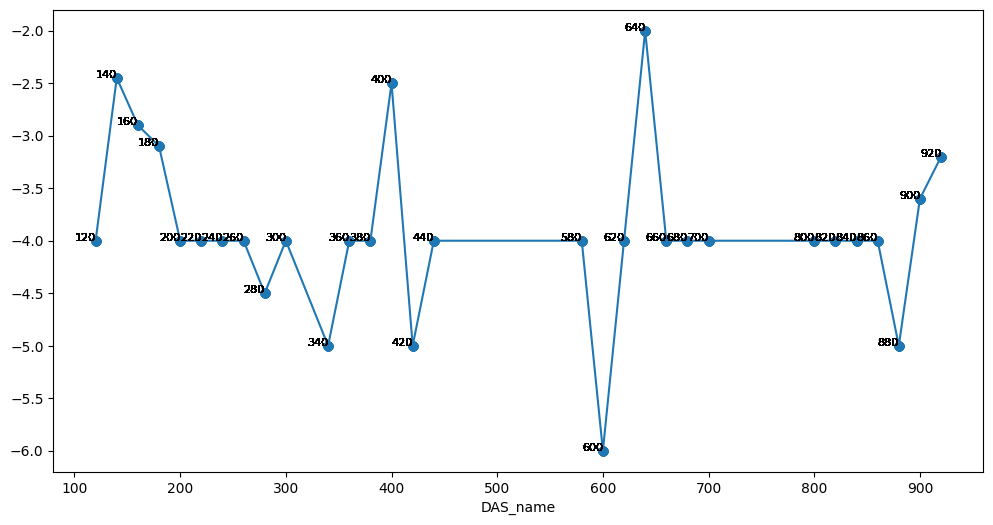

In [10]:
# plot DAS_name vs end. Use line plot

fig = plt.figure(figsize=(12, 6))

plt.plot(df['DAS_name'], df['end'], marker='o', linestyle='-')

# add DAS_names to the plot

for i, txt in enumerate(df['DAS_name']):
    plt.annotate(txt, (df['DAS_name'][i], df['end'][i]), fontsize=8, ha='right')
plt.xlabel('DAS_name')

In [11]:
# save train number from 1 to 10


range_pass = np.arange(0,30) #10,30

df_train_number_ = df[(df['train_number'] >= np.min(range_pass)) & (df['train_number'] <= np.max(range_pass))]


# remove train number 1 to 10 from the dataframe

df = df[~df['train_number'].isin(list(range_pass))]

# Split training and testing data: e.g. taking first 25 for training the rest for validation...




In [12]:
df.shape, df_train_number_.shape

((630, 24), (870, 24))

## 3. Exploratory data analysis
----------------------------------------------------

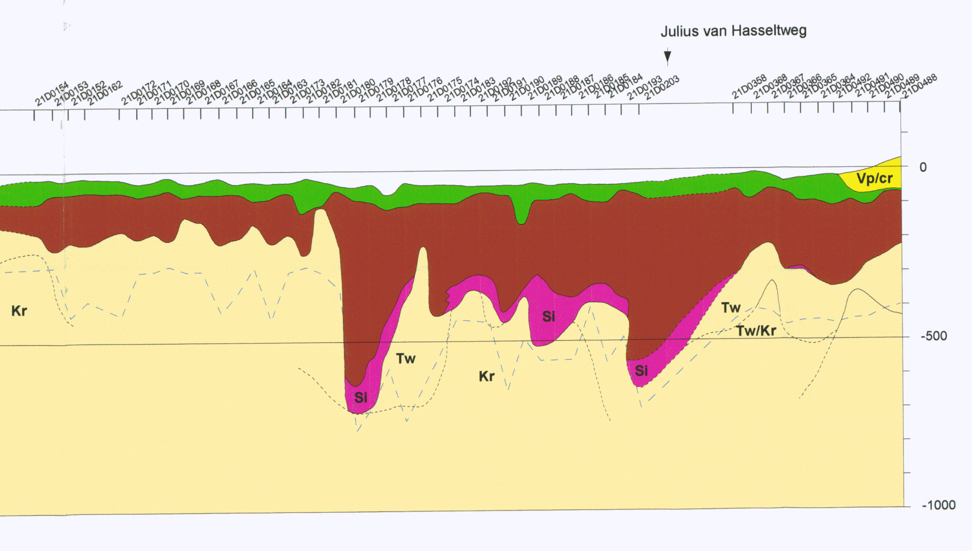

In [13]:
# Check for missing values
print(df.isnull().sum())

x_coord           0
y_coord           0
surface           0
end               0
z_top            21
cwt_f10           0
cwt_f12           0
cwt_f14           0
cwt_f16           0
cwt_f18           0
cwt_f20           0
cwt_f22           0
cwt_f24           0
cwt_f26           0
cwt_f28           0
cwt_f30           0
cwt_f32           0
cwt_f34           0
cwt_f36           0
cwt_f38           0
cwt_f40           0
Borehole_name     0
DAS_name          0
train_number      0
dtype: int64


In [14]:
# Check the data types of the columns
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 630 entries, 29 to 1499
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   x_coord        630 non-null    float64
 1   y_coord        630 non-null    float64
 2   surface        630 non-null    float64
 3   end            630 non-null    float64
 4   z_top          609 non-null    float64
 5   cwt_f10        630 non-null    float64
 6   cwt_f12        630 non-null    float64
 7   cwt_f14        630 non-null    float64
 8   cwt_f16        630 non-null    float64
 9   cwt_f18        630 non-null    float64
 10  cwt_f20        630 non-null    float64
 11  cwt_f22        630 non-null    float64
 12  cwt_f24        630 non-null    float64
 13  cwt_f26        630 non-null    float64
 14  cwt_f28        630 non-null    float64
 15  cwt_f30        630 non-null    float64
 16  cwt_f32        630 non-null    float64
 17  cwt_f34        630 non-null    float64
 18  cwt_f36      

In [15]:
df['end'].value_counts()
# Check the distribution of the target variable

end
-4.00    378
-5.00     63
-2.45     21
-2.90     21
-3.10     21
-4.50     21
-2.50     21
-6.00     21
-2.00     21
-3.60     21
-3.20     21
Name: count, dtype: int64

### 4. Prepare data for training
---------------------------------------------

In [16]:
df

,x_coord,y_coord,surface,end,z_top,cwt_f10,cwt_f12,cwt_f14,cwt_f16,cwt_f18,...,cwt_f28,cwt_f30,cwt_f32,cwt_f34,cwt_f36,cwt_f38,cwt_f40,Borehole_name,DAS_name,train_number
29,192733.7797,502794.1986,0.50,-4.0,NaN,1.856147e-08,2.457702e-08,2.434638e-08,1.884599e-08,1.109235e-08,...,6.887011e-09,4.992164e-09,3.874249e-09,4.486536e-09,4.546758e-09,3.157853e-09,2.489266e-09,21D0187,120,30
30,192733.7797,502794.1986,0.50,-4.0,NaN,8.782428e-09,8.180000e-09,1.003389e-08,9.900564e-09,7.856549e-09,...,2.685156e-09,2.513569e-09,2.159568e-09,2.326100e-09,2.450931e-09,1.738829e-09,1.203653e-09,21D0187,120,31
31,192733.7797,502794.1986,0.50,-4.0,NaN,5.564870e-09,7.733745e-09,9.213883e-09,8.237228e-09,5.621524e-09,...,2.202917e-09,1.979507e-09,1.622855e-09,2.338557e-09,2.835705e-09,2.270818e-09,1.500619e-09,21D0187,120,32
32,192733.7797,502794.1986,0.50,-4.0,NaN,4.007018e-09,5.123651e-09,6.710506e-09,7.084949e-09,6.704580e-09,...,2.694489e-09,1.988507e-09,1.872774e-09,2.101105e-09,2.210987e-09,1.759728e-09,1.431483e-09,21D0187,120,33
33,192733.7797,502794.1986,0.50,-4.0,NaN,1.519551e-08,2.111040e-08,2.267131e-08,1.853209e-08,1.098230e-08,...,4.357802e-09,3.844143e-09,3.541547e-09,3.439015e-09,3.500617e-09,2.780408e-09,2.020884e-09,21D0187,120,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,192091.2289,503242.8083,0.39,-3.2,1.6,3.010599e-09,3.354252e-09,3.238770e-09,2.641635e-09,2.451518e-09,...,1.779586e-09,1.548292e-09,1.085591e-09,8.140949e-10,8.383240e-10,8.748990e-10,7.880711e-10,21D0165,920,46
1496,192091.2289,503242.8083,0.39,-3.2,1.6,1.274083e-09,1.386502e-09,1.447824e-09,1.629633e-09,2.188472e-09,...,5.946385e-10,5.242853e-10,7.200245e-10,8.182009e-10,7.085472e-10,4.396499e-10,2.950575e-10,21D0165,920,47
1497,192091.2289,503242.8083,0.39,-3.2,1.6,1.767233e-09,1.970521e-09,1.697082e-09,1.305012e-09,1.071209e-09,...,6.848390e-10,6.561411e-10,7.049946e-10,5.529215e-10,4.241780e-10,3.560027e-10,3.283870e-10,21D0165,920,48
1498,192091.2289,503242.8083,0.39,-3.2,1.6,1.252015e-09,1.165738e-09,1.236659e-09,1.409564e-09,1.942182e-09,...,1.124661e-09,7.093335e-10,5.983650e-10,8.917424e-10,1.029062e-09,8.991599e-10,6.406528e-10,21D0165,920,49


In [17]:
df_train_features = df.drop(columns=['DAS_name','Borehole_name','surface','end','z_top','x_coord','y_coord','train_number'])
df_train_labels = df['end']

df_train_features


,cwt_f10,cwt_f12,cwt_f14,cwt_f16,cwt_f18,cwt_f20,cwt_f22,cwt_f24,cwt_f26,cwt_f28,cwt_f30,cwt_f32,cwt_f34,cwt_f36,cwt_f38,cwt_f40
29,1.856147e-08,2.457702e-08,2.434638e-08,1.884599e-08,1.109235e-08,7.307890e-09,7.671770e-09,9.368540e-09,8.939058e-09,6.887011e-09,4.992164e-09,3.874249e-09,4.486536e-09,4.546758e-09,3.157853e-09,2.489266e-09
30,8.782428e-09,8.180000e-09,1.003389e-08,9.900564e-09,7.856549e-09,8.704107e-09,8.473543e-09,5.831564e-09,4.015984e-09,2.685156e-09,2.513569e-09,2.159568e-09,2.326100e-09,2.450931e-09,1.738829e-09,1.203653e-09
31,5.564870e-09,7.733745e-09,9.213883e-09,8.237228e-09,5.621524e-09,4.533548e-09,3.867418e-09,2.622769e-09,2.336857e-09,2.202917e-09,1.979507e-09,1.622855e-09,2.338557e-09,2.835705e-09,2.270818e-09,1.500619e-09
32,4.007018e-09,5.123651e-09,6.710506e-09,7.084949e-09,6.704580e-09,8.685169e-09,1.006316e-08,8.278851e-09,5.583581e-09,2.694489e-09,1.988507e-09,1.872774e-09,2.101105e-09,2.210987e-09,1.759728e-09,1.431483e-09
33,1.519551e-08,2.111040e-08,2.267131e-08,1.853209e-08,1.098230e-08,6.580555e-09,5.538351e-09,4.281809e-09,4.300203e-09,4.357802e-09,3.844143e-09,3.541547e-09,3.439015e-09,3.500617e-09,2.780408e-09,2.020884e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,3.010599e-09,3.354252e-09,3.238770e-09,2.641635e-09,2.451518e-09,2.270636e-09,1.847433e-09,1.665491e-09,1.640531e-09,1.779586e-09,1.548292e-09,1.085591e-09,8.140949e-10,8.383240e-10,8.748990e-10,7.880711e-10
1496,1.274083e-09,1.386502e-09,1.447824e-09,1.629633e-09,2.188472e-09,2.865500e-09,2.838730e-09,1.883182e-09,1.158228e-09,5.946385e-10,5.242853e-10,7.200245e-10,8.182009e-10,7.085472e-10,4.396499e-10,2.950575e-10
1497,1.767233e-09,1.970521e-09,1.697082e-09,1.305012e-09,1.071209e-09,9.279905e-10,8.893855e-10,9.235354e-10,8.181085e-10,6.848390e-10,6.561411e-10,7.049946e-10,5.529215e-10,4.241780e-10,3.560027e-10,3.283870e-10
1498,1.252015e-09,1.165738e-09,1.236659e-09,1.409564e-09,1.942182e-09,2.670463e-09,3.218069e-09,3.075498e-09,2.299011e-09,1.124661e-09,7.093335e-10,5.983650e-10,8.917424e-10,1.029062e-09,8.991599e-10,6.406528e-10


In [18]:
# prepare input data for training

X = df_train_features.values
y = df_train_labels.values

# normalize the data
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

X_train = X
y_train = y


# Split the data into training and testing sets
#X_train, _, y_train, _ = X, y#train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize X_test. Get X_test from df_train_number_10

X_test = df_train_number_.drop(columns=['DAS_name','Borehole_name','surface','end','z_top','x_coord','y_coord','train_number']).values
X_test = scaler.transform(X_test)
y_test = df_train_number_['end'].values



In [19]:
X_train.shape

(630, 16)

## Model building

We will be using different metrics functions defined in sklearn like RMSE, MAE, 𝑅2, and Adjusted 𝑅2. We will define a function to calculate these metrics.

In [20]:
# Function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# Function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors)                  # Predict using the independent variables
    r2 = r2_score(target, pred)                       # To compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)    # To compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # To compute RMSE
    mae = mean_absolute_error(target, pred)           # To compute MAE

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
        },
        index=[0],
    )

    return df_perf

## XGB Booster regressor

In [21]:
# use XGBoost regressor
from xgboost import XGBRegressor
# Initialize the model
rf = XGBRegressor(n_estimators=100, random_state=42)


#rf = RandomForestRegressor(n_estimators=50, random_state=42)

rf.fit(X_train, y_train)
# Predict on the test set
y_pred = rf.predict(X_test)
# Calculate performance metrics
df_perf = model_performance_regression(rf, X_test, y_test)
print(df_perf)


       RMSE       MAE  R-squared  Adj. R-squared
0  0.833631  0.627166  -0.128737       -0.149909


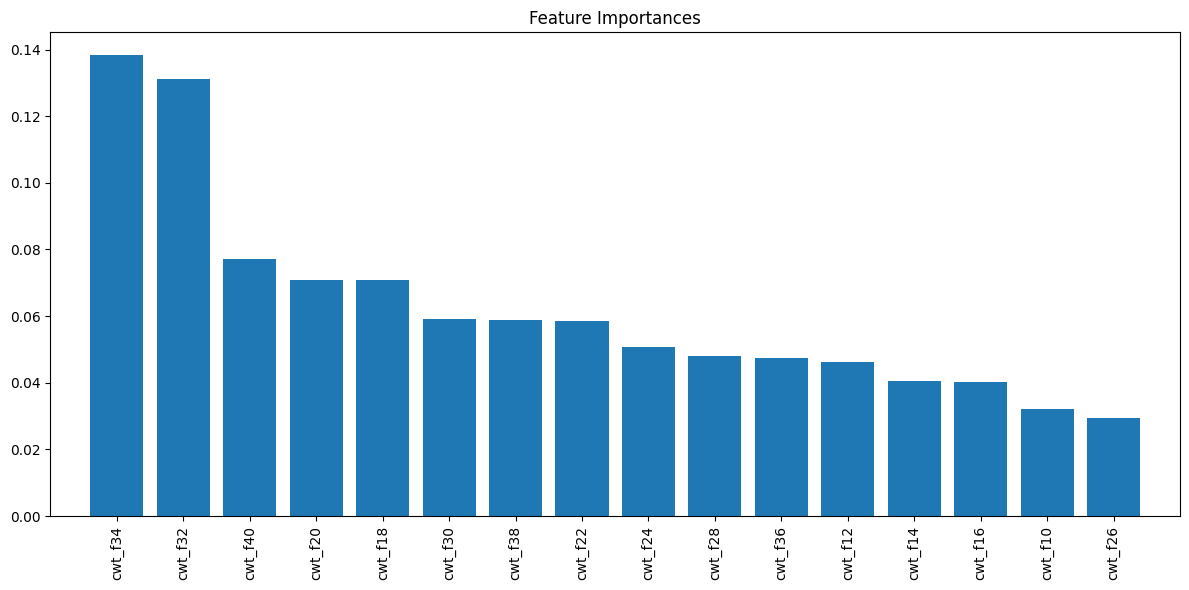

In [22]:
# plot feature importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = df_train_features.columns[indices]
importances = importances[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances, align="center")
plt.xticks(range(X_train.shape[1]), features, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

In [23]:
# fine-tune the model using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200,400,500],
    'max_depth': [None, 10, 20,40],
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_


Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [24]:
X_test_sel = np.reshape(X_test, (10,30, -1), order='F')
y_test_sel = np.reshape(y_test, (10,30, -1), order='F')

ValueError: cannot reshape array of size 13920 into shape (10,30,newaxis)

In [ ]:
plt.plot(y_test_sel[2,:,0], label='True', color='blue')

In [ ]:
X_test_sel.shape

In [ ]:
df_pred = pd.DataFrame()

for i in range(10):

    X_test_ = X_test_sel[i,:,:]
    y_test_ = y_test_sel[i,:,:]

    # Predict on the test set with the best model
    y_pred_best = best_rf.predict(X_test_)
    # Calculate performance metrics
    df_perf_best = model_performance_regression(best_rf, X_test_, y_test_)

    # plot predictions
    plt.plot(y_pred_best,'--', color='black')
    plt.plot(y_test_, label='True', color='blue')

    # store the predictions in a dataframe
    df_pred[f'pred_{i}'] = y_pred_best


mean_depth = df_pred.mean(axis=1)
std_depth = df_pred.std(axis=1)

# plot the mean and std of the predictions
plt.plot(mean_depth, label='Mean', color='green')
plt.fill_between(range(len(mean_depth)), mean_depth - 2*std_depth, mean_depth + 2*std_depth, alpha=0.5, color='gray')

plt.ylim(-6.5,-1)
plt.grid()
